# WHOOP Data Explorer & DuckDB Storage
This notebook explores the raw WHOOP JSON data, flattens it into clean tables, and stores it in DuckDB for analytics.

In [1]:
# Install DuckDB if needed
!pip install duckdb


[notice] A new release of pip is available: 23.3.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import json
import pandas as pd
import numpy as np
import duckdb
from datetime import datetime
from pathlib import Path

# Load the raw JSON data
data_path = Path('../data/raw/whoop_complete_20260224_155351.json')
with open(data_path, 'r') as f:
    raw_data = json.load(f)

print(f"Top-level keys: {list(raw_data.keys())}")

Top-level keys: ['user', 'body', 'cycles', 'recovery', 'sleep', 'workouts']


## 1. Data Structure Overview

In [3]:
print("=" * 50)
print("DATA SUMMARY")
print("=" * 50)
print(f"\nUser Info: {raw_data.get('user', {})}")
print(f"\nBody Info: {raw_data.get('body', {})}")
print(f"\nCycles:    {len(raw_data.get('cycles', []))} records")
print(f"Recovery:  {len(raw_data.get('recovery', []))} records")
print(f"Sleep:     {len(raw_data.get('sleep', []))} records")
print(f"Workouts:  {len(raw_data.get('workouts', []))} records")

DATA SUMMARY

User Info: {'user_id': 13410036, 'email': 'levijbdavis@gmail.com', 'first_name': 'Levi', 'last_name': 'Davis'}

Body Info: {'height_meter': 1.7272, 'weight_kilogram': 68.0388, 'max_heart_rate': 191}

Cycles:    764 records
Recovery:  746 records
Sleep:     847 records
Workouts:  331 records


## 2. Flatten JSON to DataFrames

In [4]:
# Flatten cycles (daily strain)
def flatten_cycles(cycles):
    records = []
    for c in cycles:
        record = {
            'cycle_id': c['id'],
            'start': c['start'],
            'end': c['end'],
            'timezone_offset': c['timezone_offset'],
            'score_state': c['score_state'],
            'strain': c.get('score', {}).get('strain'),
            'kilojoule': c.get('score', {}).get('kilojoule'),
            'average_heart_rate': c.get('score', {}).get('average_heart_rate'),
            'max_heart_rate': c.get('score', {}).get('max_heart_rate'),
        }
        records.append(record)
    return pd.DataFrame(records)

df_cycles = flatten_cycles(raw_data['cycles'])
df_cycles['start'] = pd.to_datetime(df_cycles['start'])
df_cycles['end'] = pd.to_datetime(df_cycles['end'])
df_cycles['date'] = df_cycles['start'].dt.date

print(f"Cycles: {df_cycles.shape}")
df_cycles.head(3)

Cycles: (764, 10)


,cycle_id,start,end,timezone_offset,score_state,strain,kilojoule,average_heart_rate,max_heart_rate,date
0,1331030410,2026-02-24 09:00:14.330000+00:00,NaT,-05:00,SCORED,3.327400,3475.3052,58,112,2026-02-24
1,1329085888,2026-02-23 10:48:27.550000+00:00,2026-02-24 09:00:14.330000+00:00,-05:00,SCORED,5.756961,6903.8830,63,124,2026-02-23
2,1326651620,2026-02-22 07:55:39.590000+00:00,2026-02-23 10:48:27.550000+00:00,-05:00,SCORED,7.169401,8484.7110,67,151,2026-02-22


In [5]:
# Flatten recovery
def flatten_recovery(recovery_list):
    records = []
    for r in recovery_list:
        score = r.get('score', {})
        record = {
            'cycle_id': r['cycle_id'],
            'sleep_id': r['sleep_id'],
            'created_at': r['created_at'],
            'score_state': r['score_state'],
            'recovery_score': score.get('recovery_score'),
            'resting_heart_rate': score.get('resting_heart_rate'),
            'hrv_rmssd_milli': score.get('hrv_rmssd_milli'),
            'spo2_percentage': score.get('spo2_percentage'),
            'skin_temp_celsius': score.get('skin_temp_celsius'),
            'user_calibrating': score.get('user_calibrating'),
        }
        records.append(record)
    return pd.DataFrame(records)

df_recovery = flatten_recovery(raw_data['recovery'])
df_recovery['created_at'] = pd.to_datetime(df_recovery['created_at'])
df_recovery['date'] = df_recovery['created_at'].dt.date

print(f"Recovery: {df_recovery.shape}")
df_recovery.head(3)

Recovery: (746, 11)


,cycle_id,sleep_id,created_at,score_state,recovery_score,resting_heart_rate,hrv_rmssd_milli,spo2_percentage,skin_temp_celsius,user_calibrating,date
0,1331030410,9dbe7e62-885e-4568-a7c4-76fefa9c462a,2026-02-24 14:58:37.659000+00:00,SCORED,55.0,51.0,72.157140,98.500000,34.363667,False,2026-02-24
1,1329085888,18dfabb2-ad3c-4732-9cf8-33e654230895,2026-02-23 15:36:01.081000+00:00,SCORED,76.0,49.0,80.040565,97.538460,34.538498,False,2026-02-23
2,1326651620,6e9c8cd3-6101-4e77-95a8-1b84911dde22,2026-02-22 12:45:29.820000+00:00,SCORED,58.0,52.0,74.388920,98.666664,34.520832,False,2026-02-22


In [6]:
# Flatten sleep
def flatten_sleep(sleep_list):
    records = []
    for s in sleep_list:
        score = s.get('score', {})
        stage = score.get('stage_summary', {})
        need = score.get('sleep_needed', {})
        
        record = {
            'sleep_id': s['id'],
            'cycle_id': s['cycle_id'],
            'start': s['start'],
            'end': s['end'],
            'timezone_offset': s['timezone_offset'],
            'nap': s['nap'],
            'score_state': s['score_state'],
            # Stage summary (convert milli to hours)
            'total_in_bed_hours': stage.get('total_in_bed_time_milli', 0) / 3600000,
            'total_awake_hours': stage.get('total_awake_time_milli', 0) / 3600000,
            'total_light_sleep_hours': stage.get('total_light_sleep_time_milli', 0) / 3600000,
            'total_sws_hours': stage.get('total_slow_wave_sleep_time_milli', 0) / 3600000,
            'total_rem_hours': stage.get('total_rem_sleep_time_milli', 0) / 3600000,
            'sleep_cycles': stage.get('sleep_cycle_count'),
            'disturbances': stage.get('disturbance_count'),
            # Sleep metrics
            'respiratory_rate': score.get('respiratory_rate'),
            'sleep_performance_pct': score.get('sleep_performance_percentage'),
            'sleep_consistency_pct': score.get('sleep_consistency_percentage'),
            'sleep_efficiency_pct': score.get('sleep_efficiency_percentage'),
            # Sleep need
            'baseline_need_hours': need.get('baseline_milli', 0) / 3600000,
            'debt_need_hours': need.get('need_from_sleep_debt_milli', 0) / 3600000,
            'strain_need_hours': need.get('need_from_recent_strain_milli', 0) / 3600000,
        }
        records.append(record)
    return pd.DataFrame(records)

df_sleep = flatten_sleep(raw_data['sleep'])
df_sleep['start'] = pd.to_datetime(df_sleep['start'])
df_sleep['end'] = pd.to_datetime(df_sleep['end'])
df_sleep['date'] = df_sleep['start'].dt.date

print(f"Sleep: {df_sleep.shape}")
print(f"Naps: {df_sleep['nap'].sum()} | Main sleeps: {(~df_sleep['nap']).sum()}")
df_sleep.head(3)

Sleep: (847, 22)
Naps: 101 | Main sleeps: 746


,sleep_id,cycle_id,start,end,timezone_offset,nap,score_state,total_in_bed_hours,total_awake_hours,total_light_sleep_hours,...,sleep_cycles,disturbances,respiratory_rate,sleep_performance_pct,sleep_consistency_pct,sleep_efficiency_pct,baseline_need_hours,debt_need_hours,strain_need_hours,date
0,9dbe7e62-885e-4568-a7c4-76fefa9c462a,1331030410,2026-02-24 09:00:14.330000+00:00,2026-02-24 14:47:15.460000+00:00,-05:00,False,SCORED,5.783647,0.325033,2.123694,...,2,8,17.109375,66.0,54.0,94.380135,7.741074,1.769967,0.065799,2026-02-24
1,18dfabb2-ad3c-4732-9cf8-33e654230895,1329085888,2026-02-23 10:48:27.550000+00:00,2026-02-23 17:30:01.710000+00:00,-05:00,False,SCORED,6.692822,0.566983,1.615878,...,4,8,16.933594,70.0,46.0,91.528490,7.741155,1.827966,0.096651,2026-02-23
2,6e9c8cd3-6101-4e77-95a8-1b84911dde22,1326651620,2026-02-22 07:55:39.590000+00:00,2026-02-22 12:12:19.320000+00:00,-05:00,False,SCORED,4.277703,0.058333,2.101247,...,1,6,16.933594,55.0,29.0,98.636340,7.741237,0.000000,0.134066,2026-02-22


In [7]:
# Flatten workouts
def flatten_workouts(workout_list):
    records = []
    for w in workout_list:
        score = w.get('score', {})
        zones = score.get('zone_durations', {})
        
        record = {
            'workout_id': w['id'],
            'start': w['start'],
            'end': w['end'],
            'timezone_offset': w['timezone_offset'],
            'sport_name': w.get('sport_name'),
            'sport_id': w.get('sport_id'),
            'score_state': w['score_state'],
            # Workout metrics
            'strain': score.get('strain'),
            'average_heart_rate': score.get('average_heart_rate'),
            'max_heart_rate': score.get('max_heart_rate'),
            'kilojoule': score.get('kilojoule'),
            'distance_meter': score.get('distance_meter'),
            'altitude_gain_meter': score.get('altitude_gain_meter'),
            'percent_recorded': score.get('percent_recorded'),
            # HR Zones (convert milli to minutes)
            'zone_0_mins': zones.get('zone_zero_milli', 0) / 60000,
            'zone_1_mins': zones.get('zone_one_milli', 0) / 60000,
            'zone_2_mins': zones.get('zone_two_milli', 0) / 60000,
            'zone_3_mins': zones.get('zone_three_milli', 0) / 60000,
            'zone_4_mins': zones.get('zone_four_milli', 0) / 60000,
            'zone_5_mins': zones.get('zone_five_milli', 0) / 60000,
        }
        records.append(record)
    return pd.DataFrame(records)

df_workouts = flatten_workouts(raw_data['workouts'])
df_workouts['start'] = pd.to_datetime(df_workouts['start'])
df_workouts['end'] = pd.to_datetime(df_workouts['end'])
df_workouts['date'] = df_workouts['start'].dt.date
df_workouts['duration_mins'] = (df_workouts['end'] - df_workouts['start']).dt.total_seconds() / 60

print(f"Workouts: {df_workouts.shape}")
print(f"\nTop workout types:")
print(df_workouts['sport_name'].value_counts().head())

Workouts: (331, 22)

Top workout types:
sport_name
activity      148
walking        49
basketball     22
dance          21
soccer         20
Name: count, dtype: int64


## 3. Create DuckDB Database

In [8]:
# Create/connect to DuckDB database
db_path = Path('../data/processed/whoop.db')
db_path.parent.mkdir(parents=True, exist_ok=True)

# Connect to database (creates if doesn't exist)
con = duckdb.connect(str(db_path))

print(f"Connected to DuckDB: {db_path}")

Connected to DuckDB: ..\data\processed\whoop.db


In [10]:
# Load DataFrames into DuckDB tables
con.execute("DROP TABLE IF EXISTS cycles")
con.execute("DROP TABLE IF EXISTS recovery")
con.execute("DROP TABLE IF EXISTS sleep")
con.execute("DROP TABLE IF EXISTS workouts")

con.execute("CREATE TABLE cycles AS SELECT * FROM df_cycles")
con.execute("CREATE TABLE recovery AS SELECT * FROM df_recovery")
con.execute("CREATE TABLE sleep AS SELECT * FROM df_sleep")
con.execute("CREATE TABLE workouts AS SELECT * FROM df_workouts")

print("Tables created!")
con.execute("SHOW TABLES").fetchdf()

Tables created!


,name
0,cycles
1,recovery
2,sleep
3,workouts


In [11]:
# Create a unified daily view
con.execute("""
    DROP VIEW IF EXISTS daily_summary;
    
    CREATE VIEW daily_summary AS
    SELECT 
        c.cycle_id,
        c.date,
        c.strain AS day_strain,
        c.kilojoule AS day_kilojoule,
        c.average_heart_rate AS day_avg_hr,
        c.max_heart_rate AS day_max_hr,
        r.recovery_score,
        r.resting_heart_rate,
        r.hrv_rmssd_milli,
        r.spo2_percentage,
        r.skin_temp_celsius,
        s.total_in_bed_hours,
        s.total_sws_hours,
        s.total_rem_hours,
        s.sleep_performance_pct,
        s.sleep_efficiency_pct,
        s.disturbances
    FROM cycles c
    LEFT JOIN recovery r ON c.cycle_id = r.cycle_id
    LEFT JOIN sleep s ON c.cycle_id = s.cycle_id AND s.nap = false
    ORDER BY c.date DESC
""")

print("Created daily_summary view!")

Created daily_summary view!


## 4. Query Your Data with SQL
Now you can use SQL to analyze your WHOOP data!

In [12]:
# Basic query - recent daily summaries
con.execute("""
    SELECT * FROM daily_summary
    LIMIT 10
""").fetchdf()

,cycle_id,date,day_strain,day_kilojoule,day_avg_hr,day_max_hr,recovery_score,resting_heart_rate,hrv_rmssd_milli,spo2_percentage,skin_temp_celsius,total_in_bed_hours,total_sws_hours,total_rem_hours,sleep_performance_pct,sleep_efficiency_pct,disturbances
0,1331030410,2026-02-24,3.327400,3475.3052,58,112,55.0,51.0,72.157140,98.500000,34.363667,5.783647,2.359289,0.975631,66.0,94.380135,8
1,1329085888,2026-02-23,5.756961,6903.8830,63,124,76.0,49.0,80.040565,97.538460,34.538498,6.692822,2.542364,1.967597,70.0,91.528490,8
2,1326651620,2026-02-22,7.169401,8484.7110,67,151,58.0,52.0,74.388920,98.666664,34.520832,4.277703,1.576156,0.541967,55.0,98.636340,6
3,1324830462,2026-02-21,8.397319,7675.2270,67,137,67.0,56.0,69.832860,97.821430,33.785500,8.750728,1.842303,2.243450,79.0,93.523940,16
4,1323275814,2026-02-20,5.103690,6608.6333,60,124,68.0,46.0,83.694320,95.333336,34.214580,4.191889,1.780106,1.033669,57.0,95.825134,5
5,1321427988,2026-02-19,5.654505,7836.3510,59,131,70.0,50.0,67.635400,97.025000,33.725334,8.241572,1.951472,2.067897,92.0,96.441360,13
6,1319489327,2026-02-18,8.622906,8153.3240,68,133,54.0,50.0,62.917107,99.000000,33.815334,9.103267,1.975639,1.343128,81.0,92.444950,4
7,1317521907,2026-02-17,6.677098,7800.9365,65,124,44.0,52.0,57.286530,98.000000,33.587670,8.544644,1.584528,1.859242,87.0,96.472480,6
8,1315610092,2026-02-16,9.322711,8080.2790,67,139,69.0,49.0,70.298230,96.925000,33.724335,9.258803,2.725986,2.092067,83.0,94.413510,8
9,1313700620,2026-02-15,6.454284,7892.7285,62,150,62.0,53.0,68.435600,98.342100,33.589333,10.399464,2.242067,3.566861,82.0,97.345320,10


In [13]:
# Average recovery by day of week
con.execute("""
    SELECT 
        dayname(date) AS day_of_week,
        ROUND(AVG(recovery_score), 1) AS avg_recovery,
        ROUND(AVG(day_strain), 1) AS avg_strain,
        ROUND(AVG(total_in_bed_hours), 1) AS avg_sleep_hours,
        COUNT(*) AS num_days
    FROM daily_summary
    WHERE recovery_score IS NOT NULL
    GROUP BY dayname(date)
    ORDER BY 
        CASE dayname(date)
            WHEN 'Monday' THEN 1
            WHEN 'Tuesday' THEN 2
            WHEN 'Wednesday' THEN 3
            WHEN 'Thursday' THEN 4
            WHEN 'Friday' THEN 5
            WHEN 'Saturday' THEN 6
            WHEN 'Sunday' THEN 7
        END
""").fetchdf()

,day_of_week,avg_recovery,avg_strain,avg_sleep_hours,num_days
0,Monday,65.8,8.1,7.2,106
1,Tuesday,66.8,8.4,7.3,104
2,Wednesday,63.5,8.4,7.4,109
3,Thursday,65.6,9.9,8.0,109
4,Friday,57.1,10.4,7.3,106
5,Saturday,52.8,13.1,7.9,108
6,Sunday,55.7,10.3,8.2,104


In [14]:
# Best and worst recovery days
print("TOP 5 RECOVERY DAYS:")
display(con.execute("""
    SELECT date, recovery_score, hrv_rmssd_milli, resting_heart_rate, total_in_bed_hours
    FROM daily_summary
    WHERE recovery_score IS NOT NULL
    ORDER BY recovery_score DESC
    LIMIT 5
""").fetchdf())

print("\nWORST 5 RECOVERY DAYS:")
display(con.execute("""
    SELECT date, recovery_score, hrv_rmssd_milli, resting_heart_rate, total_in_bed_hours
    FROM daily_summary
    WHERE recovery_score IS NOT NULL
    ORDER BY recovery_score ASC
    LIMIT 5
""").fetchdf())

TOP 5 RECOVERY DAYS:


,date,recovery_score,hrv_rmssd_milli,resting_heart_rate,total_in_bed_hours
0,2026-01-22,98.0,76.934190,48.0,7.709025
1,2024-12-30,98.0,79.279510,51.0,7.450036
2,2024-10-13,98.0,99.718880,47.0,10.782617
3,2024-10-31,98.0,93.286520,45.0,10.879012
4,2024-09-15,98.0,92.372925,46.0,13.329922



WORST 5 RECOVERY DAYS:


,date,recovery_score,hrv_rmssd_milli,resting_heart_rate,total_in_bed_hours
0,2025-08-24,1.0,26.426888,68.0,2.580315
1,2024-09-02,1.0,78.193200,48.0,1.289492
2,2024-11-28,1.0,36.413685,70.0,2.531224
3,2024-05-26,3.0,26.921290,75.0,4.646061
4,2024-11-10,4.0,68.397740,65.0,3.099992


In [15]:
# Monthly trends
con.execute("""
    SELECT 
        strftime(date, '%Y-%m') AS month,
        ROUND(AVG(recovery_score), 1) AS avg_recovery,
        ROUND(AVG(hrv_rmssd_milli), 1) AS avg_hrv,
        ROUND(AVG(day_strain), 1) AS avg_strain,
        ROUND(AVG(total_in_bed_hours), 1) AS avg_sleep,
        COUNT(*) AS days
    FROM daily_summary
    WHERE recovery_score IS NOT NULL
    GROUP BY strftime(date, '%Y-%m')
    ORDER BY month DESC
    LIMIT 12
""").fetchdf()

,month,avg_recovery,avg_hrv,avg_strain,avg_sleep,days
0,2026-02,69.5,71.9,6.5,8.2,24
1,2026-01,66.8,65.0,7.9,7.8,31
2,2025-12,59.8,66.3,8.6,7.0,31
3,2025-11,63.3,70.2,11.0,7.9,30
4,2025-10,56.4,66.8,10.5,7.9,31
5,2025-09,61.0,69.8,10.2,7.6,29
6,2025-08,64.2,72.6,9.7,8.2,31
7,2025-07,63.8,70.3,10.2,7.4,29
8,2025-06,58.8,65.5,11.9,7.5,29
9,2025-05,61.3,72.7,10.0,7.4,29


In [16]:
# Workout summary by type
con.execute("""
    SELECT 
        sport_name,
        COUNT(*) AS count,
        ROUND(AVG(strain), 1) AS avg_strain,
        ROUND(AVG(duration_mins), 0) AS avg_duration_mins,
        ROUND(AVG(average_heart_rate), 0) AS avg_hr,
        ROUND(SUM(kilojoule), 0) AS total_kj
    FROM workouts
    WHERE sport_name IS NOT NULL
    GROUP BY sport_name
    ORDER BY count DESC
    LIMIT 10
""").fetchdf()

,sport_name,count,avg_strain,avg_duration_mins,avg_hr,total_kj
0,activity,148,10.2,65.0,123.0,302363.0
1,walking,49,4.8,21.0,103.0,14905.0
2,basketball,22,11.0,68.0,124.0,47441.0
3,dance,21,8.6,51.0,122.0,31647.0
4,weightlifting,20,8.5,60.0,113.0,29037.0
5,soccer,20,16.1,106.0,138.0,87986.0
6,cycling,10,9.0,45.0,123.0,13835.0
7,functional-fitness,7,9.3,62.0,118.0,12928.0
8,golf,7,6.7,64.0,103.0,6812.0
9,commuting,6,7.9,26.0,131.0,5642.0


In [17]:
# Correlation: Does previous day strain affect recovery?
con.execute("""
    WITH lagged AS (
        SELECT 
            date,
            recovery_score,
            LAG(day_strain) OVER (ORDER BY date) AS prev_day_strain,
            LAG(total_in_bed_hours) OVER (ORDER BY date) AS prev_night_sleep
        FROM daily_summary
        WHERE recovery_score IS NOT NULL
    )
    SELECT 
        CASE 
            WHEN prev_day_strain < 8 THEN 'Low (<8)'
            WHEN prev_day_strain < 12 THEN 'Medium (8-12)'
            WHEN prev_day_strain < 16 THEN 'High (12-16)'
            ELSE 'Very High (16+)'
        END AS prev_strain_bucket,
        ROUND(AVG(recovery_score), 1) AS avg_next_day_recovery,
        COUNT(*) AS days
    FROM lagged
    WHERE prev_day_strain IS NOT NULL
    GROUP BY prev_strain_bucket
    ORDER BY avg_next_day_recovery DESC
""").fetchdf()

,prev_strain_bucket,avg_next_day_recovery,days
0,Low (<8),68.1,325
1,Medium (8-12),63.4,195
2,High (12-16),51.0,149
3,Very High (16+),44.3,76


In [18]:
# Sleep vs Recovery analysis
con.execute("""
    SELECT 
        CASE 
            WHEN total_in_bed_hours < 6 THEN '< 6 hrs'
            WHEN total_in_bed_hours < 7 THEN '6-7 hrs'
            WHEN total_in_bed_hours < 8 THEN '7-8 hrs'
            WHEN total_in_bed_hours < 9 THEN '8-9 hrs'
            ELSE '9+ hrs'
        END AS sleep_bucket,
        ROUND(AVG(recovery_score), 1) AS avg_recovery,
        ROUND(AVG(hrv_rmssd_milli), 1) AS avg_hrv,
        COUNT(*) AS days
    FROM daily_summary
    WHERE total_in_bed_hours IS NOT NULL AND recovery_score IS NOT NULL
    GROUP BY sleep_bucket
    ORDER BY avg_recovery DESC
""").fetchdf()

,sleep_bucket,avg_recovery,avg_hrv,days
0,9+ hrs,69.2,76.1,203
1,8-9 hrs,67.3,75.3,150
2,7-8 hrs,65.9,74.2,118
3,6-7 hrs,61.7,73.9,96
4,< 6 hrs,42.8,71.9,179


## 5. Export Query Results to Pandas
You can easily convert any query to a DataFrame for ML/visualization.

In [20]:
# Get full daily summary as DataFrame for ML
df_daily = con.execute("SELECT * FROM daily_summary").fetchdf()
print(f"Daily DataFrame: {df_daily.shape}")
df_daily.describe()

Daily DataFrame: (764, 17)


,cycle_id,date,day_strain,day_kilojoule,day_avg_hr,day_max_hr,recovery_score,resting_heart_rate,hrv_rmssd_milli,spo2_percentage,skin_temp_celsius,total_in_bed_hours,total_sws_hours,total_rem_hours,sleep_performance_pct,sleep_efficiency_pct,disturbances
count,7.640000e+02,764,764.000000,764.000000,764.000000,764.000000,746.000000,746.000000,746.000000,745.000000,738.000000,746.000000,746.000000,746.000000,746.000000,746.000000,746.0
mean,8.225141e+08,2025-01-20 05:20:25.130890,9.804338,8938.146008,68.366492,149.803665,61.018767,52.024129,74.350586,97.296154,33.659867,7.622526,1.735836,2.157767,75.276139,92.792081,9.951743
min,4.699085e+08,2023-12-03 00:00:00,0.111787,1273.567000,46.000000,102.000000,1.000000,42.000000,21.302560,87.000000,31.551723,1.017110,0.128174,0.000000,7.000000,62.952360,0.0
25%,5.928576e+08,2024-06-13 18:00:00,6.492825,7389.326775,64.000000,136.000000,47.250000,48.000000,65.372734,96.750000,33.300000,6.128192,1.426147,1.549680,65.000000,91.070984,7.0
50%,7.938043e+08,2025-02-05 12:00:00,8.776277,8238.593000,67.000000,149.000000,64.000000,51.000000,75.169923,97.394740,33.700000,7.830441,1.770436,2.189680,78.000000,93.824190,10.0
75%,1.022155e+09,2025-08-17 06:00:00,12.801448,9764.611750,72.000000,164.000000,78.000000,54.000000,84.070054,98.000000,34.081249,9.136424,2.065890,2.771556,89.000000,95.521535,13.0
max,1.331030e+09,2026-02-24 00:00:00,20.593720,20971.402000,105.000000,202.000000,98.000000,75.000000,122.511860,99.800000,35.400000,14.932388,3.067675,4.565965,100.000000,100.000000,24.0
std,2.489302e+08,NaN,4.203719,2664.601728,6.991230,19.374510,22.864343,5.949628,15.783426,1.078808,0.577236,2.208016,0.476674,0.890818,19.281285,4.430740,4.353855


## 6. Quick Visualizations

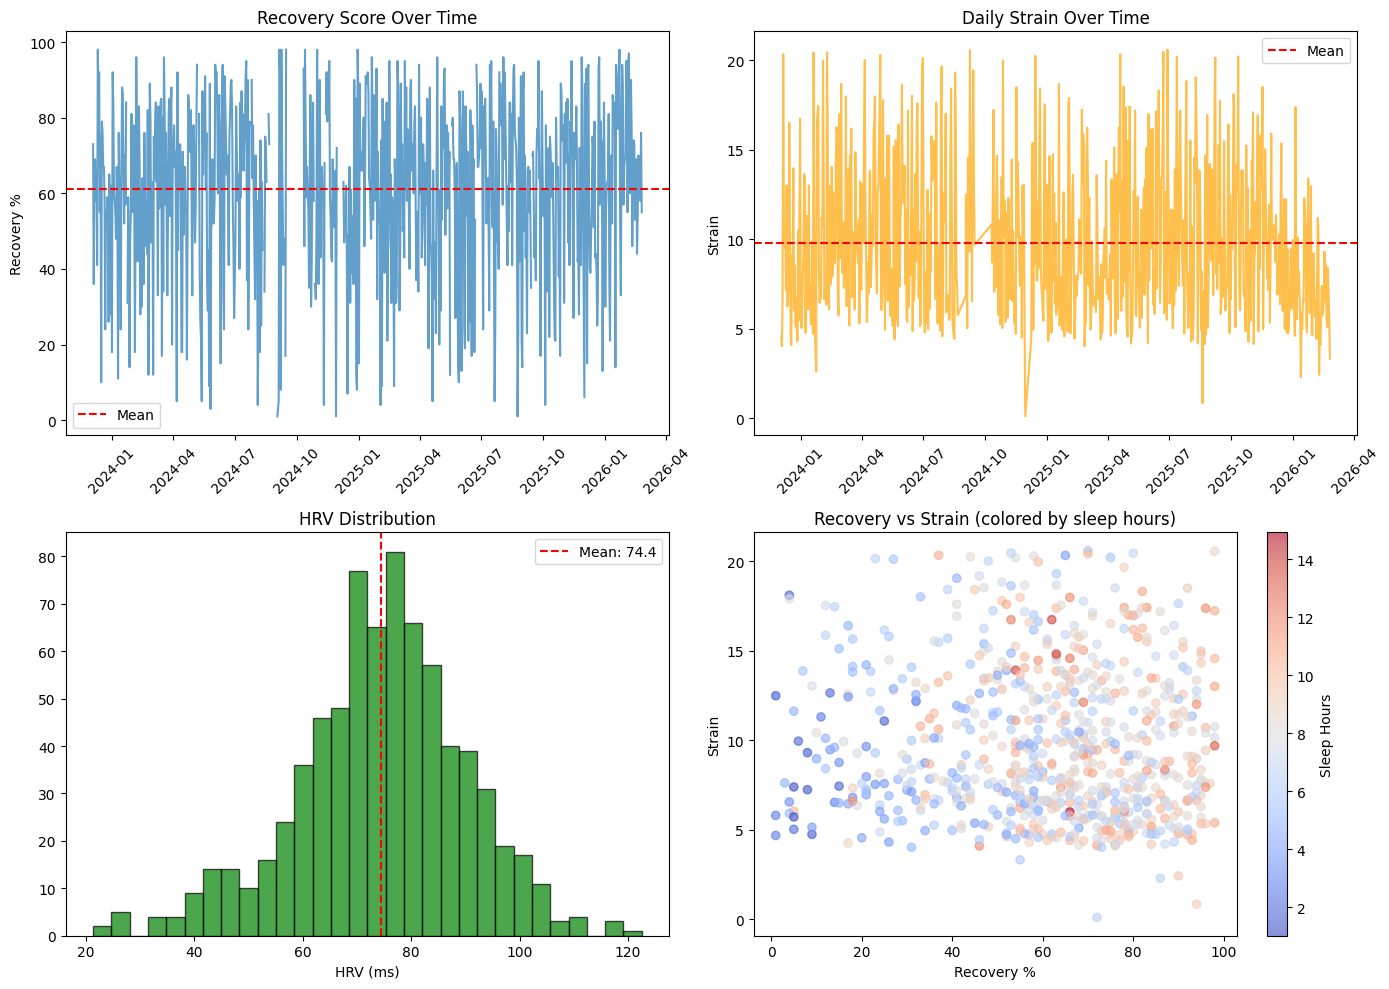

In [21]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Recovery over time
ax1 = axes[0, 0]
ax1.plot(df_daily['date'], df_daily['recovery_score'], alpha=0.7)
ax1.axhline(y=df_daily['recovery_score'].mean(), color='r', linestyle='--', label='Mean')
ax1.set_title('Recovery Score Over Time')
ax1.set_ylabel('Recovery %')
ax1.legend()
ax1.tick_params(axis='x', rotation=45)

# Strain over time
ax2 = axes[0, 1]
ax2.plot(df_daily['date'], df_daily['day_strain'], alpha=0.7, color='orange')
ax2.axhline(y=df_daily['day_strain'].mean(), color='r', linestyle='--', label='Mean')
ax2.set_title('Daily Strain Over Time')
ax2.set_ylabel('Strain')
ax2.legend()
ax2.tick_params(axis='x', rotation=45)

# HRV distribution
ax3 = axes[1, 0]
ax3.hist(df_daily['hrv_rmssd_milli'].dropna(), bins=30, alpha=0.7, color='green', edgecolor='black')
ax3.axvline(x=df_daily['hrv_rmssd_milli'].mean(), color='r', linestyle='--', label=f"Mean: {df_daily['hrv_rmssd_milli'].mean():.1f}")
ax3.set_title('HRV Distribution')
ax3.set_xlabel('HRV (ms)')
ax3.legend()

# Recovery vs Strain scatter
ax4 = axes[1, 1]
scatter = ax4.scatter(df_daily['recovery_score'], df_daily['day_strain'], 
                       c=df_daily['total_in_bed_hours'], cmap='coolwarm', alpha=0.6)
ax4.set_title('Recovery vs Strain (colored by sleep hours)')
ax4.set_xlabel('Recovery %')
ax4.set_ylabel('Strain')
plt.colorbar(scatter, ax=ax4, label='Sleep Hours')

plt.tight_layout()
plt.savefig('../data/processed/whoop_overview.png', dpi=100)
plt.show()

## 7. Useful DuckDB Tips

In [22]:
# Check table schemas
print("CYCLES SCHEMA:")
display(con.execute("DESCRIBE cycles").fetchdf())

CYCLES SCHEMA:


,column_name,column_type,null,key,default,extra
0,cycle_id,BIGINT,YES,None,None,None
1,start,TIMESTAMP WITH TIME ZONE,YES,None,None,None
2,end,TIMESTAMP WITH TIME ZONE,YES,None,None,None
3,timezone_offset,VARCHAR,YES,None,None,None
4,score_state,VARCHAR,YES,None,None,None
5,strain,DOUBLE,YES,None,None,None
6,kilojoule,DOUBLE,YES,None,None,None
7,average_heart_rate,BIGINT,YES,None,None,None
8,max_heart_rate,BIGINT,YES,None,None,None
9,date,DATE,YES,None,None,None


In [23]:
# Database size
import os
db_size = os.path.getsize(db_path) / 1024
print(f"Database size: {db_size:.1f} KB")

Database size: 12.0 KB


In [24]:
# Export to Parquet (DuckDB can do this directly!)
con.execute("""
    COPY (SELECT * FROM daily_summary) 
    TO '../data/processed/daily_summary.parquet' (FORMAT PARQUET)
""")
print("Exported daily_summary.parquet")

Exported daily_summary.parquet


In [25]:
# Close connection when done
con.close()
print("Connection closed.")

Connection closed.


## 8. Reconnecting Later
When you come back, just reconnect to the database:

In [ ]:
# Reconnect example
# con = duckdb.connect('../data/processed/whoop.db')
# df = con.execute("SELECT * FROM daily_summary WHERE recovery_score > 80").fetchdf()

## Next Steps

Now that your data is in DuckDB, you can:

1. **Build a Recovery Prediction Model** - Query `daily_summary` with lag features
2. **Add new data** - Just INSERT new records as you download more data
3. **Complex analytics** - Window functions, CTEs, aggregations all work great
4. **Connect to other tools** - DuckDB works with dbt, Metabase, etc.

### SQL Skills You Just Practiced:
- JOINs
- Window functions (LAG)
- CTEs (WITH clause)
- CASE statements
- Aggregations (GROUP BY)
- Views

These are all directly applicable to job interviews! 🎯